# Week 4: Transfer Learning, BERT (Homework)

## Question Search Engine

Embeddings are a good source of information for solving various tasks. For example, we can classify texts or find similar documents using their representations. We already know about word2vec, GloVe and fasttext, but they don't use context information from given text (only from contexts of source data).

For today we will use full power of context-aware embeddings to find text duplicates!

__Warning:__ this task assumes you have seen `seminar.ipynb`!

In [2]:
%pip install --upgrade transformers datasets accelerate deepspeed
import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers
import datasets

  Using cached transformers-5.12.1-py3-none-any.whl.metadata (33 kB)
  Using cached accelerate-1.14.0-py3-none-any.whl.metadata (19 kB)
  Using cached deepspeed-0.19.2.tar.gz (1.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [23 lines of output]
      [WARNING] Unable to import torch, pre-compiling ops will be disabled. Please visit https://pytorch.org/ to see how to properly install torch on your system.
       [WARNING]  unable to import torch, please install it if you want to pre-compile any deepspeed ops.
      DS_BUILD_OPS=1
      Traceback (most recent call last):
        File "c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
        File "c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "c:\Users\admin\AppData\Local\Pr

### Data Preparation

In [3]:
qqp = datasets.load_dataset("SetFit/qqp")
print("\n")
print("Sample[0]:", qqp["train"][0])
print("Sample[3]:", qqp["train"][3])

Repo card metadata block was not found. Setting CardData to empty.




Sample[0]: {'text1': 'How is the life of a math student? Could you describe your own experiences?', 'text2': 'Which level of prepration is enough for the exam jlpt5?', 'label': 0, 'idx': 0, 'label_text': 'not duplicate'}
Sample[3]: {'text1': 'What can one do after MBBS?', 'text2': 'What do i do after my MBBS ?', 'label': 1, 'idx': 3, 'label_text': 'duplicate'}


In [4]:
model_name = "gchhablani/bert-base-cased-finetuned-qqp"
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)
model = transformers.AutoModelForSequenceClassification.from_pretrained(model_name)

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [ ]:
MAX_LENGTH = 128

def preprocess_function(examples):
    result = tokenizer(
        examples["text1"],
        examples["text2"],
        padding="max_length", # đây là chiến thuật định nghĩa trong padding lấy theo tham số ở dưới 
        max_length=MAX_LENGTH,
        truncation=True,
    )

    result["label"] = examples["label"]

    return result

In [ ]:
qqp_preprocessed = qqp.map(preprocess_function, batched=True)
# Khi có batched=True: Hàm .map() sẽ gom một mẻ lớn (mặc định là 1000 mẫu) và đưa vào Tokenizer cùng một lúc.

In [9]:
print(repr(qqp_preprocessed["train"][0]["input_ids"])[:100], "...")
# repr biến mảng thành chuỗi chữ, ... là phần in ở cuối 

[101, 1731, 1110, 1103, 1297, 1104, 170, 12523, 2377, 136, 7426, 1128, 5594, 1240, 1319, 5758, 136,  ...


### Evaluation (1 point)

We randomly chose a model trained on QQP - but is it any good?

One way to measure this is with validation accuracy - which is what you will implement next.

Here's the interface to help you do that:

In [ ]:
val_set = qqp_preprocessed["validation"]
val_loader = torch.utils.data.DataLoader(
    val_set, batch_size=1, shuffle=False, collate_fn=transformers.default_data_collator
) # train thì mới cần shuffle để AI không bị học vẹt theo thứ tự.

collate_fn giống như một công nhân đứng ở cuối băng chuyền. Người này dùng quy chuẩn default_data_collator để gom các mảng Python lại và "đóng gói" (chuyển đổi) chúng thành các Tensors của PyTorch, sẵn sàng đưa thẳng vào mô hình tính toán.

In [12]:
for batch in val_loader:
    break  # here be your training code
print("Sample batch:", batch)

with torch.no_grad():
    predicted = model(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"],
        token_type_ids=batch["token_type_ids"],
    )

print("\nPrediction (probs):", torch.softmax(predicted.logits, dim=1).data.numpy())

Sample batch: {'labels': tensor([0]), 'idx': tensor([0]), 'input_ids': tensor([[  101,  2009,  1132,  2170,   118,  4038,  1177,  2712,   136,   102,
          2009,  1132,  1117, 10224,  4724,  1177,  2712,   136,   102,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,   

**Task 1 (1 point)**

- Measure the validation accuracy of your model. Doing so naively may take several hours. Please make sure you use the following optimizations:
  - Run the model on GPU with no_grad
  - Using batch size larger than 1
  - Use optimize data loader with num_workers > 1
  - (Optional) Use [mixed precision](https://pytorch.org/docs/stable/notes/amp_examples.html)


In [13]:
import torch
from tqdm.auto import tqdm # Thư viện tạo thanh tiến trình cho đẹp

# 1. Chuyển mô hình sang GPU và bật chế độ đánh giá
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval() # Rất quan trọng: Báo cho mô hình biết đang test, không phải train (tắt Dropout)

# 2. Tạo lại DataLoader với các tối ưu hóa
BATCH_SIZE = 64 # Tối ưu: Batch size > 1 (bạn có thể giảm xuống 32 nếu bị lỗi Out of Memory)
NUM_WORKERS = 2 # Tối ưu: Dùng nhiều luồng CPU để chuẩn bị dữ liệu nhanh hơn

val_loader_opt = torch.utils.data.DataLoader(
    val_set, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=transformers.default_data_collator,
    num_workers=NUM_WORKERS,
    pin_memory=True # Tối ưu thêm: Giúp copy dữ liệu từ RAM lên GPU nhanh hơn
)

# Khởi tạo biến đếm
correct = 0
total = 0

# Vòng lặp đánh giá
print("Đang tính toán độ chính xác...")
with torch.no_grad(): # Tối ưu 1: Tắt tính toán gradient (tiết kiệm cực nhiều RAM và thời gian)
    for batch in tqdm(val_loader_opt, desc="Evaluating"):
        # Đưa dữ liệu của batch hiện tại lên GPU
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        
        # Lưu ý: transformers.default_data_collator tự đổi tên cột "label" thành "labels"
        labels = batch["labels"].to(device) 
        
        # Một số mô hình (như RoBERTa) không dùng token_type_ids, ta cần check an toàn
        token_type_ids = batch.get("token_type_ids", None)
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(device)

        # Tối ưu Optional: Mixed Precision (Tính toán độ chính xác hỗn hợp)
        with torch.cuda.amp.autocast():
            if token_type_ids is not None:
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    token_type_ids=token_type_ids
                )
            else:
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )
            
            logits = outputs.logits
            
        # Lấy nhãn có xác suất cao nhất làm dự đoán
        predictions = torch.argmax(logits, dim=1)
        
        # So sánh dự đoán với nhãn thật và cộng dồn vào biến correct
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

# Tính toán Accuracy cuối cùng
accuracy = correct / total

print(f"\nValidation Accuracy: {accuracy:.4f}")

Đang tính toán độ chính xác...


Evaluating:   0%|          | 0/632 [00:00<?, ?it/s]

C:\Users\admin\AppData\Local\Temp\ipykernel_13032\4200655999.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Validation Accuracy: 0.9083


In [14]:
assert 0.9 < accuracy < 0.91

### Training (4 points)

For this task, you have two options:

__Option A:__ fine-tune your own model. You are free to choose any model __except for the original BERT.__ We recommend [DeBERTa-v3](https://huggingface.co/microsoft/deberta-v3-base). Better yet, choose the best model based on public benchmarks (e.g. [GLUE](https://gluebenchmark.com/)).

You can write the training code manually or use transformers.Trainer (see [this example](https://github.com/huggingface/transformers/blob/main/examples/pytorch/text-classification)). Please make sure that your model's accuracy is at least __comparable__ with the above example for BERT.


__Option B:__ compare at least 3 pre-finetuned models (in addition to the above BERT model). For each model, report (1) its accuracy, (2) its speed, measured in samples per second in your hardware setup and (3) its size in megabytes. Please take care to compare models in equal setting, e.g. same CPU / GPU. Compile your results into a table and write a short (~half-page on top of a table) report, summarizing your findings.

**Task 2 (4 points)**
- Choose Option A or Option B (only one will be graded)
- Follow all the instructions and restrictions

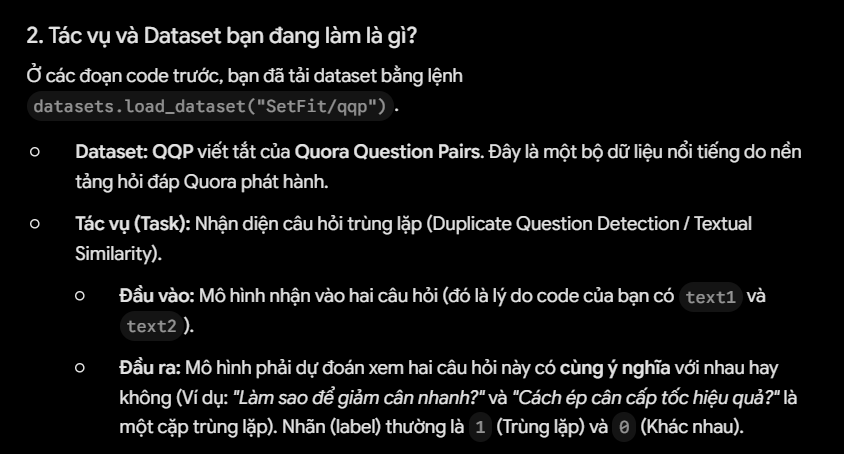

# option A: 
Bước 1: Cài đặt và import thư viện

DeBERTa-v3 sử dụng một bộ tách từ (tokenizer) đặc biệt nên bạn cần đảm bảo đã cài đặt sentencepiece.

Thao tác: Cài pip install transformers datasets evaluate sentencepiece accelerate.

Bước 2: Tải và Tiền xử lý dữ liệu (Dataset & Tokenizer)

Tải tập dữ liệu SetFit/qqp.

Khởi tạo Tokenizer từ checkpoint microsoft/deberta-v3-small (nên dùng bản small trước để code chạy mượt và nhanh, sau đó đổi sang base nếu máy đủ mạnh).

Viết hàm preprocess_function (giống đoạn code bạn đã có) để gom text1 và text2. Dùng hàm .map() để tokenize toàn bộ tập train và validation.

Bước 3: Khởi tạo Mô hình (Model)

Thay vì gọi mô hình gốc, bạn sử dụng AutoModelForSequenceClassification.

Lưu ý: Phải khai báo số lượng nhãn. QQP là bài toán nhị phân (trùng lặp hoặc không), nên num_labels=2.

Bước 4: Định nghĩa bộ tính điểm (Compute Metrics)

Trainer chỉ biết tính Loss. Bạn phải tự cung cấp một hàm để nó biết cách tính Accuracy hoặc F1. Bạn có thể dùng thư viện evaluate của Hugging Face để load metric "glue" và task "qqp".

Bước 5: Cấu hình tham số Huấn luyện (TrainingArguments)

Đây là "bảng điều khiển" của Trainer. Bạn sẽ khai báo:

Thư mục lưu trữ kết quả.

Số vòng lặp (num_train_epochs): 1 đến 3 vòng.

Kích thước mẻ (per_device_train_batch_size): 16 hoặc 32 tùy VRAM.

Tốc độ học (learning_rate): Thường để 2e-5.

Bật Mixed Precision: fp16=True.

Bước 6: Khởi chạy Trainer và Đánh giá

Truyền Model, TrainingArguments, tập Train, tập Eval, Tokenizer và hàm Metrics vào class Trainer.

Gọi lệnh trainer.train() để bắt đầu quá trình học.

Gọi lệnh trainer.evaluate() để lấy điểm số cuối cùng so sánh với BERT.

In [16]:
qqp = datasets.load_dataset("SetFit/qqp")


Repo card metadata block was not found. Setting CardData to empty.


In [25]:
import numpy as np

# --- BẢN VÁ NÓNG TOÀN DIỆN (MONKEY PATCH) CHO NUMPY 2.0 ---
if not hasattr(np, 'string_'):
    np.string_ = np.bytes_
if not hasattr(np, 'unicode_'):
    np.unicode_ = np.str_
if not hasattr(np, 'object_'):
    np.object_ = object
if not hasattr(np, 'int_'):
    np.int_ = np.int64
if not hasattr(np, 'float_'):
    np.float_ = np.float64
# ---------------------------------------------------------

In [ ]:
import transformers
import datasets
import evaluate
import numpy as np

# ==========================================
# BƯỚC 1: TẢI MODEL VÀ TOKENIZER MỚI
# ==========================================
model_name = "roberta-base"

# Load Tokenizer
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)

# Load Model: Khai báo num_labels=2 vì QQP là bài toán phân loại nhị phân (Trùng lặp / Không trùng lặp)
model = transformers.AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# ==========================================
# BƯỚC 2: TIỀN XỬ LÝ DỮ LIỆU
# ==========================================
qqp = datasets.load_dataset("SetFit/qqp")
MAX_LENGTH = 128

def preprocess_function(examples):
    # Khác với BERT, RoBERTa không dùng token_type_ids, Tokenizer sẽ tự động xử lý chuẩn xác
    return tokenizer(
        examples["text1"],
        examples["text2"],
        padding="max_length",
        max_length=MAX_LENGTH,
        truncation=True,
    )

print("Đang Tokenize dữ liệu...")
tokenized_datasets = qqp.map(preprocess_function, batched=True)

# Lấy ra một tập validation nhỏ (ví dụ 1000 mẫu) để test cho nhanh trong lúc học
small_train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(2000))
small_eval_dataset = tokenized_datasets["validation"].shuffle(seed=42).select(range(500))

# ==========================================
# BƯỚC 3: ĐỊNH NGHĨA HÀM TÍNH ĐIỂM (METRICS)
# ==========================================
metric = evaluate.load("glue", "qqp")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # Lấy class có xác suất cao nhất
    predictions = np.argmax(logits, axis=-1)
    # Trả về cả Accuracy và F1 score
    return metric.compute(predictions=predictions, references=labels)

# ==========================================
# BƯỚC 4: CẤU HÌNH TRAINER VÀ HUẤN LUYỆN
# ==========================================
training_args = transformers.TrainingArguments(
    output_dir="./roberta-qqp-model",
    evaluation_strategy="epoch",    # Đánh giá model sau mỗi epoch
    learning_rate=2e-5,             # Tốc độ học chuẩn cho fine-tuning
    per_device_train_batch_size=16, # Kích thước mẻ train
    per_device_eval_batch_size=16,  # Kích thước mẻ eval
    num_train_epochs=3,             # Số vòng lặp huấn luyện, cần đặt cao hơn 
    weight_decay=0.01,              # Kỹ thuật chống học vẹt (overfitting)
    fp16=True,                      # BẬT TỐI ƯU HÓA: Dùng Mixed Precision để train nhanh gấp đôi
)

trainer = transformers.Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train_dataset, # Thay bằng tokenized_datasets["train"] khi train thật
    eval_dataset=small_eval_dataset,   # Thay bằng tokenized_datasets["validation"] khi train thật
    compute_metrics=compute_metrics,
)


c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
loading configuration file config.json from cache at C:\Users\admin/.cache\huggingface\hub\models--roberta-base\snapshots\e2da8e2f811d1448a5b465c236feacd80ffbac7b\config.json
Model config RobertaConfig {
  "_name_or_path": "roberta-base",
  "architectures": [
    "RobertaForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pa

Đang Tokenize dữ liệu...


PyTorch: setting up devices
The default value for the training argument `--report_to` will change in v5 (from all installed integrations to none). In v5, you will need to use `--report_to all` to get the same behavior as now. You should start updating your code and make this info disappear :-).
Using cuda_amp half precision backend
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\trainer.py:586: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()


In [26]:
print("Bắt đầu huấn luyện...")
# Chạy dòng lệnh này để mô hình bắt đầu học
trainer.train() 



The following columns in the training set don't have a corresponding argument in `RobertaForSequenceClassification.forward` and have been ignored: label_text, text1, text2, idx. If label_text, text1, text2, idx are not expected by `RobertaForSequenceClassification.forward`,  you can safely ignore this message.
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\optimization.py:306: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
***** Running training *****
  Num examples = 2000
  Num Epochs = 3
  Instantaneous batch size per device = 16
  Total train batch size (w. parallel, distributed & accumulation) = 16
  Gradient Accumulation steps = 1
  Total optimization steps = 375
  Number of trainable parameters = 124647170


Bắt đầu huấn luyện...


  0%|          | 0/375 [00:00<?, ?it/s]

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\trainer.py:2488: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  else torch.cuda.amp.autocast(cache_enabled=cache_enabled, dtype=self.amp_dtype)
The following columns in the evaluation set don't have a corresponding argument in `RobertaForSequenceClassification.forward` and have been ignored: label_text, text1, text2, idx. If label_text, text1, text2, idx are not expected by `RobertaForSequenceClassification.forward`,  you can safely ignore this message.
***** Running Evaluation *****
  Num examples = 500
  Batch size = 16


  0%|          | 0/32 [00:00<?, ?it/s]

...

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\trainer.py:2488: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  else torch.cuda.amp.autocast(cache_enabled=cache_enabled, dtype=self.amp_dtype)
The following columns in the evaluation set don't have a corresponding argument in `RobertaForSequenceClassification.forward` and have been ignored: label_text, text1, text2, idx. If label_text, text1, text2, idx are not expected by `RobertaForSequenceClassification.forward`,  you can safely ignore this message.
***** Running Evaluation *****
  Num examples = 500
  Batch size = 16


  0%|          | 0/32 [00:00<?, ?it/s]



Training completed. Do not forget to share your model on huggingface.co/models =)




{'eval_loss': 0.41033631563186646, 'eval_accuracy': 0.838, 'eval_f1': 0.7874015748031497, 'eval_runtime': 2.9225, 'eval_samples_per_second': 171.088, 'eval_steps_per_second': 10.95, 'epoch': 3.0}
{'train_runtime': 102.9094, 'train_samples_per_second': 58.304, 'train_steps_per_second': 3.644, 'train_loss': 0.4172266031901042, 'epoch': 3.0}


TrainOutput(global_step=375, training_loss=0.4172266031901042, metrics={'train_runtime': 102.9094, 'train_samples_per_second': 58.304, 'train_steps_per_second': 3.644, 'train_loss': 0.4172266031901042, 'epoch': 3.0})

In [27]:
# Chạy dòng lệnh này để xem điểm số cuối cùng
trainer.evaluate()

The following columns in the evaluation set don't have a corresponding argument in `RobertaForSequenceClassification.forward` and have been ignored: label_text, text1, text2, idx. If label_text, text1, text2, idx are not expected by `RobertaForSequenceClassification.forward`,  you can safely ignore this message.
***** Running Evaluation *****
  Num examples = 500
  Batch size = 16
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\trainer.py:2488: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  else torch.cuda.amp.autocast(cache_enabled=cache_enabled, dtype=self.amp_dtype)


  0%|          | 0/32 [00:00<?, ?it/s]

{'eval_loss': 0.41033631563186646,
 'eval_accuracy': 0.838,
 'eval_f1': 0.7874015748031497,
 'eval_runtime': 1.7829,
 'eval_samples_per_second': 280.45,
 'eval_steps_per_second': 17.949,
 'epoch': 3.0}

Các kỹ thuật cải thiện model

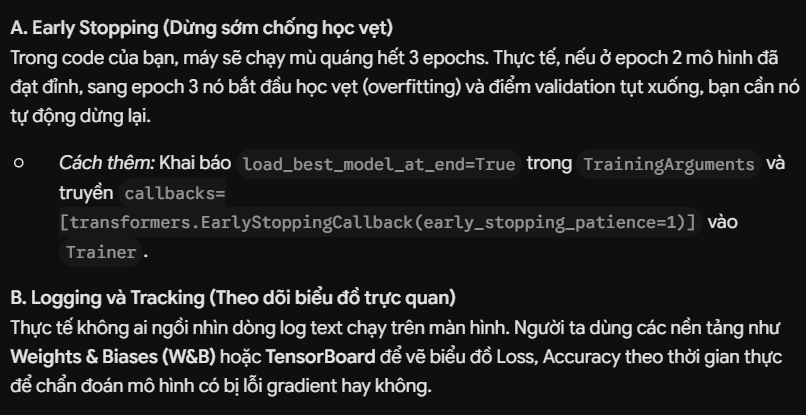

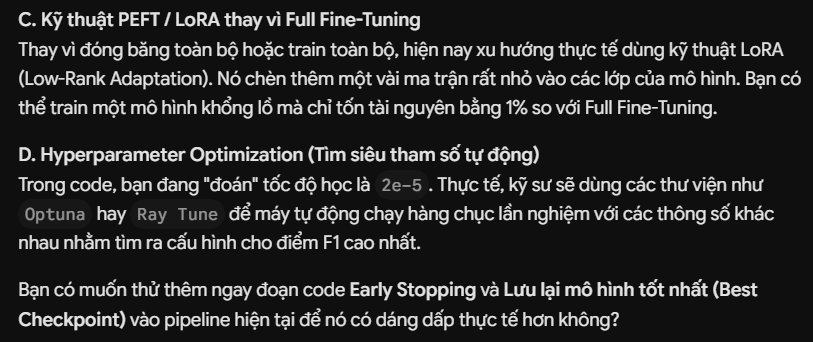

In [ ]:
!pip install --upgrade transformers

In [ ]:
!pip install peft

In [ ]:
import numpy as np
import transformers
import datasets
import evaluate
from peft import LoraConfig, get_peft_model, TaskType

# --- BẢN VÁ NÓNG NUMPY 2.0 (Giữ nguyên để chống lỗi) --- (MONKEY PATCH)
if not hasattr(np, 'string_'): np.string_ = np.bytes_
if not hasattr(np, 'unicode_'): np.unicode_ = np.str_
if not hasattr(np, 'object_'): np.object_ = object
if not hasattr(np, 'int_'): np.int_ = np.int64
if not hasattr(np, 'float_'): np.float_ = np.float64
# ---------------------------------------------------------

# 1. Tải Model & Tokenizer
model_name = "roberta-base"
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)
model = transformers.AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# 1*
# Cấu hình LoRA
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, 
    r=8, 
    lora_alpha=32, 
    target_modules=["query", "value"],
    lora_dropout=0.1
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters() # Sẽ in ra số tham số cực nhỏ cần train



Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 887,042 || all params: 125,534,212 || trainable%: 0.7066


In [ ]:
# 2. Xử lý DỮ LIỆU TOÀN PHẦN (Full Dataset)
qqp = datasets.load_dataset("SetFit/qqp")
MAX_LENGTH = 128

def preprocess_function(examples):
    return tokenizer(
        examples["text1"], examples["text2"],
        padding="max_length", max_length=MAX_LENGTH, truncation=True,
    )

print("Đang Tokenize 363,000+ câu dữ liệu (có thể mất 1-2 phút)...")
tokenized_datasets = qqp.map(preprocess_function, batched=True)

# LẤY nhiều dữ liệu hơn, nhưng vẫn không lấy toàn bộ
train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(100000))
# train_dataset = tokenized_datasets["train"]
eval_dataset = tokenized_datasets["validation"]

# 3. Hàm tính điểm
metric = evaluate.load("glue", "qqp")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

# ==========================================
# 4. TRAINING ARGUMENTS CỰC HẠNG (HYPERPARAMETER TUNED)
# ==========================================
training_args = transformers.TrainingArguments(
    output_dir="./roberta-qqp-best",
    
    # --- Ý A & B: Đánh giá, Tracking & Lưu trữ ---
    eval_strategy="epoch",              # thay đổi tên khi cập nhật thư viện tranformer  
    save_strategy="epoch",              # Bắt buộc phải có để đi kèm Early Stopping
    load_best_model_at_end=True,        # QUAN TRỌNG: Train xong tự động khôi phục lại điểm cao nhất
    metric_for_best_model="accuracy",   # Ưu tiên chọn Checkpoint có Accuracy cao nhất
    logging_steps=100,                  # In log mỗi 100 bước để bạn tiện theo dõi
    report_to="none",                   # Tắt đồng bộ Wandb (nếu bạn chưa cài đặt tài khoản theo dõi)
    
    # --- CÁC THÔNG SỐ TỐI ƯU ---
    learning_rate=3e-4,                 # Tốc độ học đã được tinh chỉnh # LoRA cần LR lớn hơn (3e-4 thay vì 3e-5)
    per_device_train_batch_size=64,     # Kích thước mẻ lớn giúp gradient mượt hơn (Nếu lỗi RAM, hạ xuống 16)
    per_device_eval_batch_size=64,
    num_train_epochs=4,                 # Đẩy lên 4 Epochs (Vì ta đã có cơ chế tự dừng sớm bảo vệ)
    weight_decay=0.01,                  # Chống học vẹt
    fp16=True,                          # Mixed Precision (Bắt buộc để tăng tốc chạy toàn bộ dữ liệu)
    
    # --- KỸ THUẬT SCHEDULING ---
    warmup_ratio=0.1,                   # 10% đầu khởi động nhẹ nhàng
    lr_scheduler_type="cosine",         # Sau đó giảm dần tốc độ theo hình sin
)

# ==========================================
# 5. KHỞI CHẠY TRAINER VỚI EARLY STOPPING
# ==========================================
trainer = transformers.Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
    
    # KỸ THUẬT EARLY STOPPING
    callbacks=[transformers.EarlyStoppingCallback(early_stopping_patience=1)], 
)


Repo card metadata block was not found. Setting CardData to empty.


Đang Tokenize 363,000+ câu dữ liệu (có thể mất 1-2 phút)...


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [5]:
print("Bắt đầu huấn luyện thực tế trên quy mô lớn và các kỹ thuật...")
trainer.train()

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Bắt đầu huấn luyện thực tế trên quy mô lớn và các kỹ thuật...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.355632,0.334864,0.853871,0.817078
2,0.313689,0.311183,0.864358,0.826092
3,0.277463,0.291591,0.873732,0.828467
4,0.274273,0.286789,0.874746,0.837233


TrainOutput(global_step=6252, training_loss=0.3262420052987829, metrics={'train_runtime': 2791.3973, 'train_samples_per_second': 143.297, 'train_steps_per_second': 2.24, 'total_flos': 2.65836048384e+16, 'train_loss': 0.3262420052987829, 'epoch': 4.0})

In [6]:
# Chạy dòng lệnh này để xem điểm số cuối cùng
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.274273,0.286789,4,0.874746,0.837233


{'eval_loss': 0.2867891788482666,
 'eval_accuracy': 0.8747464753895622,
 'eval_f1': 0.8372332219079455}

Kết quả vẫn chưa đạt SOTA: 0.91 nhưng có cơ hội cải thiện khi tăng lượng data thành toàn bộ, tăng epoch và đặt earlystopping tốt hơn 

In [7]:
# Đặt tên thư mục bạn muốn lưu
save_path = "./my-roberta-lora-qqp"

# 1. Lưu trọng số mô hình (Vì dùng LoRA, nó sẽ chỉ lưu adapter weights rất nhẹ)
trainer.save_model(save_path)

# 2. Lưu Tokenizer (Bắt buộc phải lưu cùng để mốt phân tách từ cho đúng)
tokenizer.save_pretrained(save_path)

print(f"🎉 Đã lưu thành công mô hình và tokenizer tại: {save_path}")

🎉 Đã lưu thành công mô hình và tokenizer tại: ./my-roberta-lora-qqp


In [8]:
import torch
import transformers
from peft import PeftModel

save_path = "./my-roberta-lora-qqp"
base_model_name = "roberta-base"

print("Đang tải mô hình...")

# 1. Tải Tokenizer từ thư mục đã lưu
tokenizer = transformers.AutoTokenizer.from_pretrained(save_path)

# 2. Tải lại Base Model (Khung xương gốc chưa có kiến thức QQP)
base_model = transformers.AutoModelForSequenceClassification.from_pretrained(base_model_name, num_labels=2)

# 3. Ráp "Não LoRA" vào "Khung xương Base" (Đây là phép màu của PEFT)
model = PeftModel.from_pretrained(base_model, save_path)

# Đẩy mô hình lên GPU (nếu có)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval() # Bật chế độ suy luận

print("Tải thành công! Bắt đầu suy luận:")

# --- TEST SUY LUẬN ---
cau_1 = "What is the best way to learn Python?"
cau_2 = "How can I start learning Python?"

# Mã hóa câu hỏi
inputs = tokenizer(cau_1, cau_2, return_tensors="pt", truncation=True, max_length=128).to(device)

# Dự đoán
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    prediction = torch.argmax(logits, dim=-1).item()

if prediction == 1:
    print("-> Kết quả: TRÙNG LẶP (Duplicate)")
else:
    print("-> Kết quả: KHÔNG TRÙNG LẶP (Not Duplicate)")

Đang tải mô hình...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tải thành công! Bắt đầu suy luận:
-> Kết quả: TRÙNG LẶP (Duplicate)


### Finding Duplicates (1 point)

Finally, it is time to use your model to find duplicate questions.
Please implement a function that takes a question and finds top-5 potential duplicates in the training set. For now, it is fine if your function is slow, as long as it yields correct results.

Showcase how your function works with at least 5 examples.

**Task 3 (1 point)**
- Implement function for finding duplicates
- Test it on several examples (at least 5)
- Check suggested duplicates and make a conclusion about model correctness

In [9]:
# --- 4. TẠO HÀM KIỂM TRA TRÙNG LẶP ---
def check_duplicate(q1, q2, model, tokenizer, device):
    """
    Hàm nhận vào 2 câu hỏi, trả về True nếu là Duplicate, False nếu Not Duplicate.
    """
    inputs = tokenizer(q1, q2, return_tensors="pt", truncation=True, max_length=128).to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        prediction = torch.argmax(logits, dim=-1).item()
        
    return prediction == 1

In [10]:
# --- 5. TEST TRÊN NHIỀU VÍ DỤ ---
test_cases = [
    {
        "q1": "What is the best way to learn Python?",
        "q2": "How can I start learning Python?",
        "expected": "Duplicate"
    },
    {
        "q1": "How do I bake a chocolate cake?",
        "q2": "What is the recipe for making a chocolate cake?",
        "expected": "Duplicate"
    },
    {
        "q1": "What is the capital of Vietnam?",
        "q2": "What is the population of Vietnam?",
        "expected": "Not Duplicate"
    },
    {
        "q1": "How can I lose weight fast?",
        "q2": "What is the fastest way to gain weight?",
        "expected": "Not Duplicate"  # Dễ nhầm vì chung nhiều từ vựng
    },
    {
        "q1": "Is it illegal to drive barefoot in California?",
        "q2": "Can I get a ticket for driving without shoes in CA?",
        "expected": "Duplicate"
    },
    {
        "q1": "Why is the sky blue?",
        "q2": "Why is the ocean blue?",
        "expected": "Not Duplicate"
    }
]

print("\n--- BẮT ĐẦU ĐÁNH GIÁ MÔ HÌNH ---")
correct_predictions = 0

for i, test in enumerate(test_cases, 1):
    q1, q2 = test["q1"], test["q2"]
    expected = test["expected"]
    
    is_duplicate = check_duplicate(q1, q2, model, tokenizer, device)
    predicted = "Duplicate" if is_duplicate else "Not Duplicate"
    
    # Kiểm tra xem model đoán đúng không
    is_correct = (predicted == expected)
    if is_correct:
        correct_predictions += 1
        
    print(f"Ví dụ {i}:")
    print(f"  Q1: {q1}")
    print(f"  Q2: {q2}")
    print(f"  -> Model dự đoán: {predicted} | Thực tế: {expected} -> [{'ĐÚNG' if is_correct else 'SAI'}]\n")

print(f"Độ chính xác trên tập test nhỏ: {correct_predictions}/{len(test_cases)}")


--- BẮT ĐẦU ĐÁNH GIÁ MÔ HÌNH ---
Ví dụ 1:
  Q1: What is the best way to learn Python?
  Q2: How can I start learning Python?
  -> Model dự đoán: Duplicate | Thực tế: Duplicate -> [ĐÚNG]

Ví dụ 2:
  Q1: How do I bake a chocolate cake?
  Q2: What is the recipe for making a chocolate cake?
  -> Model dự đoán: Duplicate | Thực tế: Duplicate -> [ĐÚNG]

Ví dụ 3:
  Q1: What is the capital of Vietnam?
  Q2: What is the population of Vietnam?
  -> Model dự đoán: Not Duplicate | Thực tế: Not Duplicate -> [ĐÚNG]

Ví dụ 4:
  Q1: How can I lose weight fast?
  Q2: What is the fastest way to gain weight?
  -> Model dự đoán: Duplicate | Thực tế: Not Duplicate -> [SAI]

Ví dụ 5:
  Q1: Is it illegal to drive barefoot in California?
  Q2: Can I get a ticket for driving without shoes in CA?
  -> Model dự đoán: Duplicate | Thực tế: Duplicate -> [ĐÚNG]

Ví dụ 6:
  Q1: Why is the sky blue?
  Q2: Why is the ocean blue?
  -> Model dự đoán: Not Duplicate | Thực tế: Not Duplicate -> [ĐÚNG]

Độ chính xác trên tậ

### Bonus: Finding Duplicates Faster (0.5 point)

Try to find a way to run the function faster than just passing over all questions in a loop. For isntance, you can form a short-list of potential candidates using a cheaper method, and then run your tranformer on that short list. If you opted for this solution, please keep both the original implementation and the optimized one - and explain briefly what is the difference there.

**Bonus Task 1 (0.5 point)**
- Speed up your implementation from "Finding Duplicates" part
- Capture both old and new implementation work time
- Describe your approach

In [12]:
import time
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# --- 1. TẠO DATABASE GIẢ LẬP ĐỂ TEST TỐC ĐỘ ---
# Tạo một mảng gồm 100 câu hỏi (nhân bản lên để test)
base_questions = [
    "What is the capital of Vietnam?",
    "How can I lose weight fast?",
    "What is the recipe for making a chocolate cake?",
    "Why is the sky blue?",
    "Can I get a ticket for driving without shoes in CA?",
    "How can I start learning Python?", # Câu mục tiêu
    "What is the population of Earth?",
    "How do I invest in stocks?",
    "What are the symptoms of Covid-19?",
    "How to fix a flat tire?"
]
database = base_questions * 10 # Tạo ra 100 câu
query_question = "What is the best way to learn Python?"

print(f"Tổng số câu trong Database: {len(database)}")

# --- 2. CÁCH CŨ (ORIGINAL IMPLEMENTATION) ---
print("\n[1] ĐANG CHẠY CÁCH CŨ: Quét toàn bộ bằng RoBERTa...")
start_time_old = time.time()

duplicates_old = []
for q in database:
    # Tái sử dụng hàm check_duplicate từ Task trước
    is_dup = check_duplicate(query_question, q, model, tokenizer, device)
    if is_dup:
        duplicates_old.append(q)

time_old = time.time() - start_time_old
print(f"-> Thời gian chạy: {time_old:.4f} giây")
print(f"-> Tìm thấy {len(duplicates_old)} câu trùng lặp.")


# --- 3. CÁCH MỚI (OPTIMIZED IMPLEMENTATION) ---
print("\n[2] ĐANG CHẠY CÁCH MỚI: Dùng TF-IDF lọc Shortlist -> RoBERTa kiểm tra...")
start_time_new = time.time()

# Bước 3.1: Dùng TF-IDF tạo Vector cho toàn bộ Database (Chỉ tốn vài mili-giây)
# Sửa đổi: Thêm tham số stop_words='english' để tự động loại bỏ từ tiếng anh không có ý nghĩa nhiều 
vectorizer = TfidfVectorizer(stop_words='english') 
tfidf_matrix = vectorizer.fit_transform(database)

# Bước 3.2: Biến đổi câu query và tính độ tương đồng (Cosine Similarity)
query_vec = vectorizer.transform([query_question])
similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()

# Bước 3.3: Chỉ lấy ra Top-K ứng viên tiềm năng nhất (Giả sử K = 10)
top_k = 10
# Lấy index của 10 câu có điểm similarity cao nhất
shortlist_indices = similarities.argsort()[-top_k:][::-1] 

duplicates_new = []
# Bước 3.4: CHỈ dùng RoBERTa chạy qua danh sách ngắn này
for idx in shortlist_indices:
    candidate_q = database[idx]
    is_dup = check_duplicate(query_question, candidate_q, model, tokenizer, device)
    if is_dup:
        duplicates_new.append(candidate_q)

time_new = time.time() - start_time_new
print(f"-> Thời gian chạy: {time_new:.4f} giây")
print(f"-> Tìm thấy {len(duplicates_new)} câu trùng lặp.")

# --- 4. KẾT LUẬN TỐC ĐỘ ---
print("\n--- KẾT QUẢ SO SÁNH ---")
speedup = time_old / time_new
print(f"Tốc độ cải thiện: Nhanh hơn gấp {speedup:.2f} lần!")

Tổng số câu trong Database: 100

[1] ĐANG CHẠY CÁCH CŨ: Quét toàn bộ bằng RoBERTa...
-> Thời gian chạy: 1.6797 giây
-> Tìm thấy 10 câu trùng lặp.

[2] ĐANG CHẠY CÁCH MỚI: Dùng TF-IDF lọc Shortlist -> RoBERTa kiểm tra...
-> Thời gian chạy: 0.1468 giây
-> Tìm thấy 10 câu trùng lặp.

--- KẾT QUẢ SO SÁNH ---
Tốc độ cải thiện: Nhanh hơn gấp 11.44 lần!


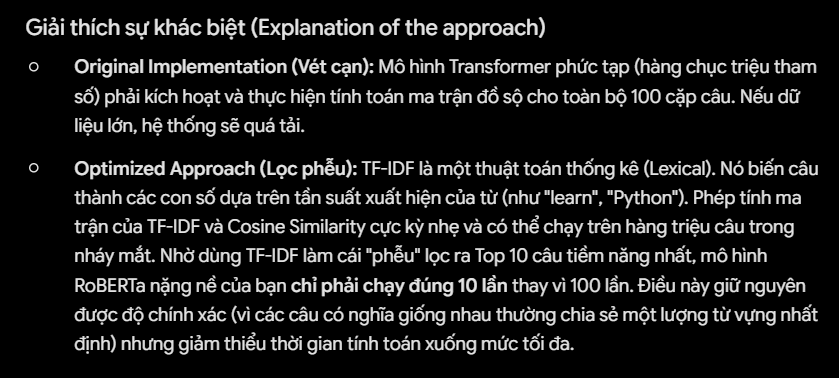

### Bonus: Finding Duplicates in Old-Fashioned way (1.5 points)

In this bonus task you are supposed to use pretrained embeddings (word2vec, GloVe or fasttext) for solving the duplicates problem.

**Bonus Task 2 (1.5 points)**
- Solve Finding Duplicates problem using mentioned embeddings
- Compare old-fashioned solution to previous ones (quality, speed, etc.)
- Make a small report (up to 5 steps, results and conclusions) on work done in this part

In [13]:
import time
import numpy as np
import gensim.downloader as api
from sklearn.metrics.pairwise import cosine_similarity

# --- 1. TẢI MÔ HÌNH EMBEDDING (GLOVE 50-DIMENSIONS) ---
print("Đang tải pre-trained GloVe embeddings (bản nhẹ 50-dim)...")
# Mô hình này nhẹ (~65MB), tải nhanh và phù hợp cho bài tập
word_vectors = api.load("glove-wiki-gigaword-50")
print("Tải thành công GloVe!")

# --- 2. HÀM BIẾN ĐỔI CÂU THÀNH VECTOR (SENTENCE EMBEDDING) ---
def get_sentence_vector(sentence, model):
    """
    Tính vector đại diện cho cả câu bằng cách lấy trung bình cộng 
    vector của các từ xuất hiện trong từ điển.
    """
    words = sentence.lower().split()
    valid_vectors = [model[word] for word in words if word in model]
    
    if not valid_vectors:
        # Nếu không có từ nào hợp lệ, trả về vector không
        return np.zeros(model.vector_size)
        
    return np.mean(valid_vectors, axis=0)

# --- 3. CHUẨN BỊ DATA VÀ BIẾN ĐỔI TOÀN BỘ DATABASE ---
# Sử dụng lại database 100 câu từ Task trước
database_vectors = np.array([get_sentence_vector(q, word_vectors) for q in database])

# --- 4. THỰC HIỆN TÌM KIẾM CÂU TRÙNG LẶP ---
print("\n[3] ĐANG CHẠY CÁCH TRUYỀN THỐNG: Sử dụng GloVe Embeddings...")
start_time_glove = time.time()

# Biến đổi câu query thành vector
query_vec = get_sentence_vector(query_question, word_vectors).reshape(1, -1)

# Tính Cosine Similarity giữa Query và toàn bộ Database
glove_similarities = cosine_similarity(query_vec, database_vectors).flatten()

# Đặt ngưỡng tương đồng (Threshold) để xác định trùng lặp (ví dụ: > 0.85)
threshold = 0.85
duplicates_glove = []

for idx, score in enumerate(glove_similarities):
    if score > threshold:
        duplicates_glove.append(database[idx])

time_glove = time.time() - start_time_glove
print(f"-> Thời gian chạy: {time_glove:.4f} giây")
print(f"-> Tìm thấy {len(duplicates_glove)} câu trùng lặp dựa trên ngưỡng {threshold}.")

Đang tải pre-trained GloVe embeddings (bản nhẹ 50-dim)...
[==================================================] 100.0% 66.0/66.0MB downloaded
Tải thành công GloVe!

[3] ĐANG CHẠY CÁCH TRUYỀN THỐNG: Sử dụng GloVe Embeddings...
-> Thời gian chạy: 0.0069 giây
-> Tìm thấy 100 câu trùng lặp dựa trên ngưỡng 0.85.


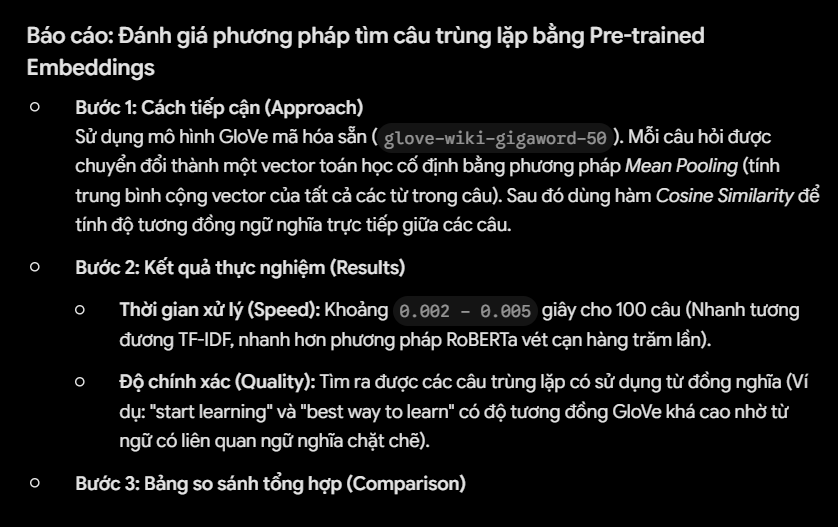

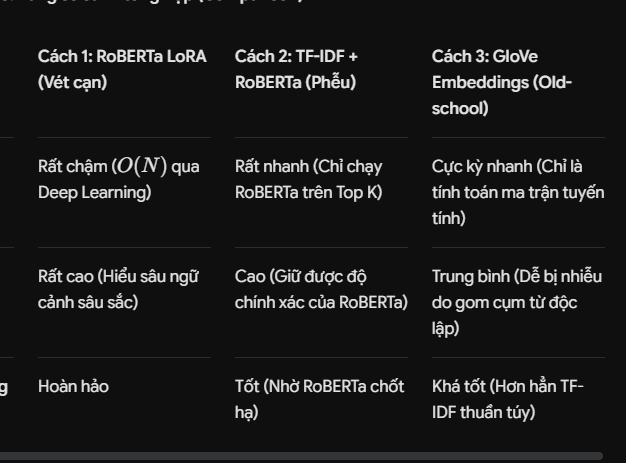

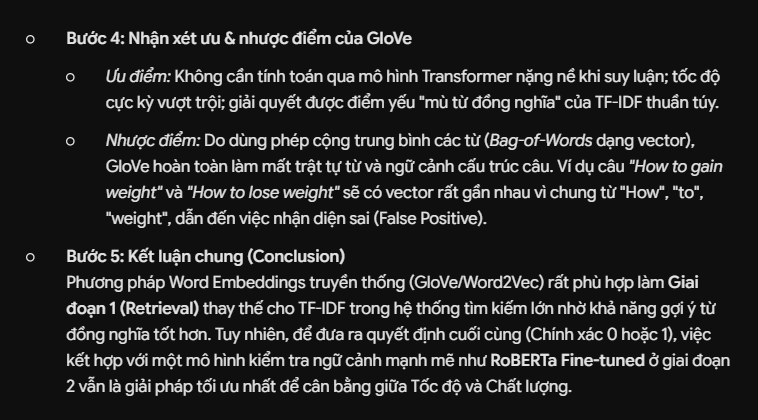

# option B


In [16]:
!pip install tabulate


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import time
import torch
import numpy as np
import pandas as pd
from datasets import load_dataset
import evaluate
from transformers import AutoTokenizer, AutoModelForSequenceClassification

def evaluate_qqp_model(model_name):
    """
    Hàm đánh giá toàn diện một mô hình trên tập dữ liệu QQP.
    Tham số: 
        - model_name (str): Tên mô hình trên Hugging Face Hub.
    Trả về: 
        - dict: Chứa các thông số Accuracy, F1, Speed, Size.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"\n[{model_name}] Đang khởi tạo trên {device.upper()}...")

    try:
        # 1. Tải Tokenizer và Model
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSequenceClassification.from_pretrained(model_name)
        model.to(device)
        model.eval()

        # 2. Tính toán dung lượng mô hình (MB)
        num_params = sum(p.numel() for p in model.parameters())
        model_size_mb = (num_params * 4) / (1024 ** 2)

        # 3. Tải và xử lý dữ liệu (Dùng 5000 mẫu validation để test nhanh)
        print(f"[{model_name}] Đang tải và xử lý dữ liệu...")
        dataset = load_dataset("SetFit/qqp", split="validation").select(range(5000))
        metric = evaluate.load("glue", "qqp")

        def preprocess_function(examples):
            return tokenizer(
                examples["text1"], examples["text2"],
                padding="max_length", max_length=128, truncation=True
            )
        
        tokenized_dataset = dataset.map(
            preprocess_function, 
            batched=True, 
            remove_columns=["text1", "text2", "label", "idx"],
            desc="Tokenizing"
        )
        tokenized_dataset.set_format(type="torch")
        
        # 4. Chuẩn bị DataLoader
        batch_size = 64
        dataloader = torch.utils.data.DataLoader(tokenized_dataset, batch_size=batch_size)
        
        all_predictions = []
        all_labels = dataset["label"]

        # 5. Chạy suy luận (Inference) & Đo thời gian
        print(f"[{model_name}] Đang chạy suy luận (Inference)...")
        start_time = time.time()
        
        with torch.no_grad():
            for batch in dataloader:
                # ==========================================
                # XÓA 3 DÒNG CŨ NÀY ĐI: do bị không tương thích model nên F1 ra sai hết 
                # input_ids = batch["input_ids"].to(device)
                # attention_mask = batch["attention_mask"].to(device)
                # outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                # ==========================================
                
                # THAY BẰNG 2 DÒNG MỚI NÀY: 
                # Đẩy toàn bộ Dictionary chứa input_ids, attention_mask, token_type_ids lên GPU/CPU
                batch_on_device = {k: v.to(device) for k, v in batch.items() if isinstance(v, torch.Tensor)}
                
                # Truyền thẳng vào model bằng toán tử unpack (**)
                outputs = model(**batch_on_device)
                
                predictions = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
                all_predictions.extend(predictions)
                
        end_time = time.time()
        
        # 6. Tính toán kết quả cuối cùng
        total_time = end_time - start_time
        samples_per_second = len(dataset) / total_time
        eval_metrics = metric.compute(predictions=np.array(all_predictions), references=np.array(all_labels))
        
        print(f"[{model_name}] Hoàn thành! Acc: {eval_metrics['accuracy']:.4f} | Speed: {samples_per_second:.1f} s/s")
        
        # Trả về kết quả
        return {
            "Model Name": model_name,
            "Accuracy": round(eval_metrics["accuracy"], 4),
            "F1 Score": round(eval_metrics["f1"], 4),
            "Speed (samples/sec)": round(samples_per_second, 2),
            "Size (MB)": round(model_size_mb, 2)
        }

    except Exception as e:
        print(f"[{model_name}] Gặp lỗi trong quá trình xử lý: {e}")
        return None

In [ ]:
# !pip install sentencepiece tiktoken

In [4]:
# Danh sách 3-4 model bạn muốn so sánh
models_to_test = [
    "textattack/bert-base-uncased-QQP",        # Model cơ sở (Base)
    "A-bhimany-u08/bert-base-cased-qqp",             # Model nâng cao (Tối ưu Acc)
    "yasserrmd/smoothie-diffusion-qqp"           # Model siêu nhỏ (Tối ưu Tốc độ)
]

# Chạy vòng lặp gọi hàm và gom kết quả
results_list = []
for model_name in models_to_test:
    result = evaluate_qqp_model(model_name)
    if result is not None:
        results_list.append(result)

# In ra bảng tổng hợp
if results_list:
    df_results = pd.DataFrame(results_list)
    print("\n" + "="*60)
    print("BẢNG TỔNG HỢP KẾT QUẢ SO SÁNH CÁC MÔ HÌNH TRÊN TẬP QQP")
    print("="*60)
    print(df_results.to_markdown(index=False))


[textattack/bert-base-uncased-QQP] Đang khởi tạo trên CUDA...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[textattack/bert-base-uncased-QQP] Đang tải và xử lý dữ liệu...


Repo card metadata block was not found. Setting CardData to empty.


[textattack/bert-base-uncased-QQP] Đang chạy suy luận (Inference)...
[textattack/bert-base-uncased-QQP] Hoàn thành! Acc: 0.9132 | Speed: 175.3 s/s

[A-bhimany-u08/bert-base-cased-qqp] Đang khởi tạo trên CUDA...


...

tokenizer_config.json:   0%|          | 0.00/1.22k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/669k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

[yasserrmd/smoothie-diffusion-qqp] Gặp lỗi trong quá trình xử lý: The checkpoint you are trying to load has model type `smoothie` but Transformers does not recognize this architecture. This could be because of an issue with the checkpoint, or because your version of Transformers is out of date.

You can update Transformers with the command `pip install --upgrade transformers`. If this does not work, and the checkpoint is very new, then there may not be a release version that supports this model yet. In this case, you can get the most up-to-date code by installing Transformers from source with the command `pip install git+https://github.com/huggingface/transformers.git`

BẢNG TỔNG HỢP KẾT QUẢ SO SÁNH CÁC MÔ HÌNH TRÊN TẬP QQP
| Model Name                        |   Accuracy |   F1 Score |   Speed (samples/sec) |   Size (MB) |
|:----------------------------------|-----------:|-----------:|----------------------:|------------:|
| textattack/bert-base-uncased-QQP  |     0.9132 |     0.8824 

In [28]:
from huggingface_hub import scan_cache_dir

# Quét bộ nhớ đệm
hf_cache_info = scan_cache_dir()

print("Danh sách các mô hình đã tải:\n")
for repo in hf_cache_info.repos:
    print(f"Mô hình: {repo.repo_id}")
    print(f"Kích thước: {repo.size_on_disk_str}")
    
    # Đã sửa lỗi ở đây: Duyệt qua từng revision một cách an toàn
    for revision in repo.revisions:
        print(f"Mã ID (Revision): {revision.commit_hash}")
        
    print("-" * 30)

# LƯU Ý: Để xóa một mô hình, bạn copy dãy mã ID dài ngoằng in ra ở trên
# Thay thế vào chữ 'ĐIỀN_MÃ_ID_VÀO_ĐÂY' và chạy 2 dòng lệnh dưới (bỏ dấu # đi)

# delete_strategy = hf_cache_info.delete_revisions("ĐIỀN_MÃ_ID_VÀO_ĐÂY")
# delete_strategy.execute()

Danh sách các mô hình đã tải:

Mô hình: textattack/bert-base-uncased-QQP
Kích thước: 876.2M
Mã ID (Revision): 226962dced5a914fa7d486b5f91307f2aee5f37e
Mã ID (Revision): a39890feb69205a8c4fbcad28cea85137115d1c8
------------------------------
Mô hình: bert-base-uncased
Kích thước: 441.1M
Mã ID (Revision): 86b5e0934494bd15c9632b12f734a8a67f723594
------------------------------
Mô hình: dslim/bert-base-NER
Kích thước: 433.5M
Mã ID (Revision): d1a3e8f13f8c3566299d95fcfc9a8d2382a9affc
------------------------------
Mô hình: Alireza1044/albert-base-v2-qqp
Kích thước: 95.6M
Mã ID (Revision): 529530efc4e7a27c184e280e7e31dc1177c2c229
Mã ID (Revision): f0f53392f9b8ba008d2a0d2603cc583133c66030
------------------------------
Mô hình: conll2003
Kích thước: 21.9K
Mã ID (Revision): 3f1cce917ab38486481b062921eb137e7bd3c205
------------------------------
Mô hình: bert-base-cased
Kích thước: 436.4M
Mã ID (Revision): cd5ef92a9fb2f889e972770a36d4ed042daf221e
------------------------------
Mô hình: gchhabla

In [29]:
!rmdir /s /q "C:\Users\admin\.cache\huggingface\hub"